## RQ1: How do Gemini and DeepSeek differ from humans in performance and choice behaviour across IGT variants?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy

In [2]:
# For Human data, take only the sessions with 100 trials to ensure fair comparison
# across variants and between humans and agents.

human = pd.read_csv("../data/iowa_human/combined_igt_human.csv")
human = human[(human['experiment'] == 1)]

print("Trials kept:", human.shape[0])
print("Sessions kept:", human.groupby(["variant","session_id", "experiment"]).size().shape[0])

Trials kept: 41000
Sessions kept: 410


In [3]:
gemini = pd.read_csv("../data/iowa_models/gemini/gemini_igt_combined.csv")
deepseek = pd.read_csv("../data/iowa_models/deepseek/deepseek_igt_combined.csv")
human = human

# Keep only the comparable columns
cols = ['session_id', 'trial_number', 'choice', 'won', 'loss', 'total', 'variant']

human = human[cols]
gemini = gemini[cols]
deepseek = deepseek[cols]

human["dataset"] = "Human"
gemini["dataset"] = "Gemini"
deepseek["dataset"] = "DeepSeek"

df = pd.concat([human, gemini, deepseek], ignore_index=True)

print("Combined rows:", df.shape[0])
print(df.columns)
df.head()

Combined rows: 131000
Index(['session_id', 'trial_number', 'choice', 'won', 'loss', 'total',
       'variant', 'dataset'],
      dtype='object')


,session_id,trial_number,choice,won,loss,total,variant,dataset
0,0,1,H,100.0,-200.0,1900.0,1,Human
1,0,2,H,100.0,-150.0,1850.0,1,Human
2,0,3,V,100.0,-0.0,1950.0,1,Human
3,0,4,D,50.0,-250.0,1750.0,1,Human
4,0,5,J,50.0,-0.0,1800.0,1,Human


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131000 entries, 0 to 130999
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   session_id    131000 non-null  int64  
 1   trial_number  131000 non-null  int64  
 2   choice        131000 non-null  object 
 3   won           131000 non-null  float64
 4   loss          131000 non-null  float64
 5   total         131000 non-null  float64
 6   variant       131000 non-null  int64  
 7   dataset       131000 non-null  object 
dtypes: float64(3), int64(3), object(2)
memory usage: 8.0+ MB


In [5]:
df = df.copy()

# clean choices
df["choice_clean"] = df["choice"].astype(str).str.strip().str.upper()

# ensure numeric
df["variant"] = pd.to_numeric(df["variant"], errors="raise").astype(int)
df["session_id"] = pd.to_numeric(df["session_id"], errors="coerce")

# reward
df["reward"] = df["won"].astype(float) + df["loss"].astype(float)

df.head()

,session_id,trial_number,choice,won,loss,total,variant,dataset,choice_clean,reward
0,0,1,H,100.0,-200.0,1900.0,1,Human,H,-100.0
1,0,2,H,100.0,-150.0,1850.0,1,Human,H,-50.0
2,0,3,V,100.0,-0.0,1950.0,1,Human,V,100.0
3,0,4,D,50.0,-250.0,1750.0,1,Human,D,-200.0
4,0,5,J,50.0,-0.0,1800.0,1,Human,J,50.0


In [6]:
print("Rows after 1..100 trial filter:", df.shape[0])
print("Trial counts check (should be 100 per run, roughly):")
print(df.groupby(["dataset", "variant", "session_id"])["trial_number"].count().describe())

Rows after 1..100 trial filter: 131000
Trial counts check (should be 100 per run, roughly):
count    1310.0
mean      100.0
std         0.0
min       100.0
25%       100.0
50%       100.0
75%       100.0
max       100.0
Name: trial_number, dtype: float64


### Behavioural Feature Extraction

Session-level features are computed from the first 100 trials of each run.

Because human data uses different deck labels across experiments, choices are **dynamically mapped per run** to generic actions (action_0–action_3), ensuring comparability across humans and agents.

Extracted features:

- **p_action_0–3**: Proportion of each action (preference)
- **mean_reward**: Average reward per trial (performance)
- **reward_learning_slope**: Change in reward (learning)
- **switch_rate**: How often actions change (exploration)
- **switch_change**: Change in switching over time
- **loss_sensitivity**: Switching after losses
- **final_total**: Final accumulated reward

These features capture behaviour without relying on specific deck labels.

In [7]:
def session_features(grp):
    grp = grp.sort_values("trial_number").head(100).copy()

    choices_raw = grp["choice_clean"].values
    n = len(choices_raw)

    # dynamic mapping per run (same idea as RW)
    unique_choices = sorted(grp["choice_clean"].unique())
    choice_map = {choice: i for i, choice in enumerate(unique_choices)}

    choices = grp["choice_clean"].map(choice_map).astype(int).values
    n_actions = len(unique_choices)

    # action proportions
    action_props = {}
    for i in range(4):
        action_props[f"p_action_{i}"] = (choices == i).mean() if i < n_actions else 0.0

    # rewards
    rewards = grp["reward"].values

    # switching behaviour
    switches = np.sum(choices[1:] != choices[:-1]) / max(n - 1, 1)

    # loss sensitivity
    losses = grp["loss"].astype(float).values
    loss_idx = np.where(losses < 0)[0]

    loss_switches = 0
    for i in loss_idx:
        if i + 1 < n and choices[i + 1] != choices[i]:
            loss_switches += 1

    loss_sensitivity = loss_switches / max(len(loss_idx), 1)

    # learning (reward-based)
    early_reward = rewards[:50].mean()
    late_reward = rewards[50:100].mean()
    reward_learning_slope = late_reward - early_reward

    # exploration change
    early_switch = np.sum(choices[1:50] != choices[:49]) / max(49, 1)
    late_switch = np.sum(choices[51:100] != choices[50:99]) / max(49, 1)
    switch_change = late_switch - early_switch

    final_total = grp["total"].astype(float).iloc[-1]

    return pd.Series({
        "n_trials_used": n,
        "n_actions": n_actions,
        "action_labels": ",".join(unique_choices),

        "p_action_0": action_props["p_action_0"],
        "p_action_1": action_props["p_action_1"],
        "p_action_2": action_props["p_action_2"],
        "p_action_3": action_props["p_action_3"],

        "mean_reward": rewards.mean(),
        "reward_learning_slope": reward_learning_slope,
        "switch_rate": switches,
        "switch_change": switch_change,
        "loss_sensitivity": loss_sensitivity,
        "final_total": final_total
    })

In [8]:
session_df = (
    df.groupby(["dataset", "variant", "session_id"], dropna=False)
      .apply(session_features)
      .reset_index()
)

print(session_df.shape)
session_df.head()

(1310, 16)


,dataset,variant,session_id,n_trials_used,n_actions,action_labels,p_action_0,p_action_1,p_action_2,p_action_3,mean_reward,reward_learning_slope,switch_rate,switch_change,loss_sensitivity,final_total
0,DeepSeek,1,1,100,3,"K,Q,S",0.39,0.15,0.46,0.0,-53.0,-58.0,0.404040,0.204082,0.525000,-3300.0
1,DeepSeek,1,2,100,2,"K,Q",0.85,0.15,0.00,0.0,12.5,-95.0,0.252525,0.142857,0.666667,3250.0
2,DeepSeek,1,3,100,4,"D,K,Q,S",0.01,0.40,0.09,0.5,-11.0,26.0,0.434343,0.102041,0.485714,900.0
3,DeepSeek,1,4,100,3,"K,Q,S",0.78,0.17,0.05,0.0,-7.5,45.0,0.292929,0.061224,0.722222,1250.0
4,DeepSeek,1,5,100,3,"K,Q,S",0.35,0.01,0.64,0.0,-13.5,9.0,0.212121,0.020408,0.333333,650.0


## Performance across variants

In [9]:
# Final total summary
session_df.groupby(["dataset", "variant"])["final_total"].describe()

count         mean          std     min      25%     50%  \
dataset  variant                                                             
DeepSeek 1        200.0  1409.250000  2129.300717 -3700.0  -100.00  1350.0   
         2        200.0  1590.000000  2305.128649 -3650.0   -50.00  1675.0   
         3         50.0  1296.000000  2552.746420 -4500.0   -87.50  1350.0   
Gemini   1        200.0  3784.500000  1024.932771  1200.0  3187.50  3725.0   
         2        200.0  3903.000000   972.778231  1950.0  3250.00  3800.0   
         3         50.0  3869.000000  1165.966797  1850.0  3012.50  3775.0   
Human    1        159.0  1901.886792   926.142244  -500.0  1350.00  2050.0   
         2        222.0  1489.707207  1311.786037 -2250.0   646.25  1360.0   
         3         29.0  1585.344828   914.650530  -150.0  1250.00  1550.0   

                     75%     max  
dataset  variant                  
DeepSeek 1        2950.0  8950.0  
         2        3012.5  9250.0  
         3        3300.0  6150.0  
Gemini   1        4400.0  7100.0  
         2        4400.0  7800.0  
         3        4425.0  6900.0  
Human    1        2600.0  3950.0  
         2        2322.5  5570.0  
         3        1750.0  5125.0

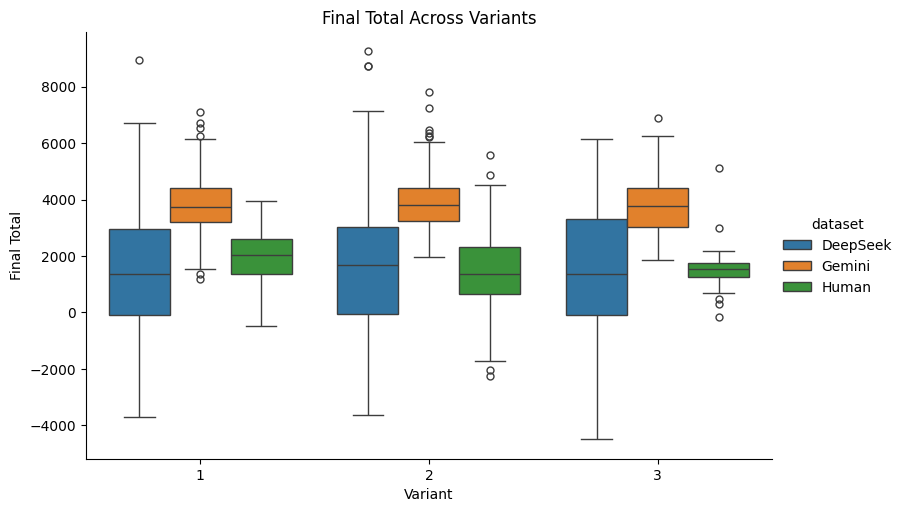

In [10]:
sns.catplot(
    data=session_df,
    kind="box",
    x="variant",
    y="final_total",
    hue="dataset",
    height=5,
    aspect=1.6
)

plt.title("Final Total Across Variants")
plt.xlabel("Variant")
plt.ylabel("Final Total")
plt.show()

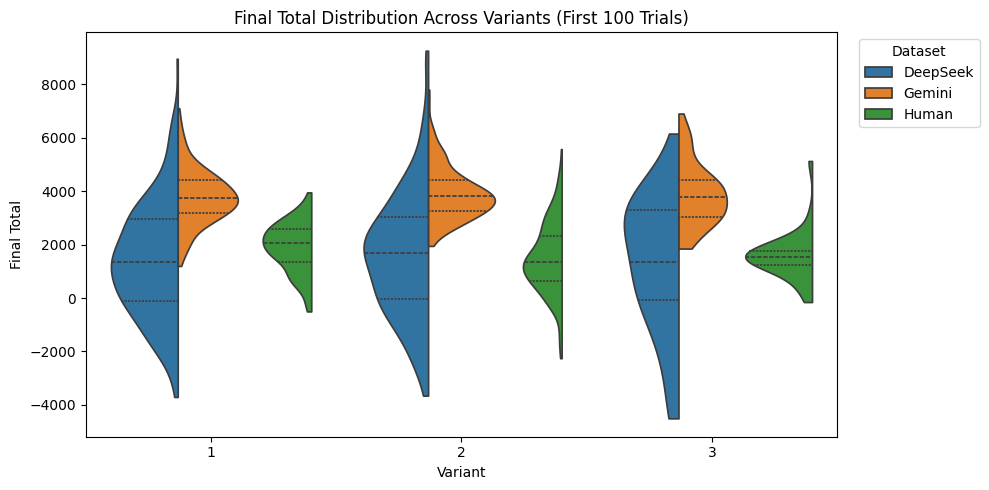

In [11]:
# Violin plot for more distribution details
plt.figure(figsize=(10,5))

sns.violinplot(
    data=session_df,
    x="variant",
    y="final_total",
    hue="dataset",
    cut=0,
    inner="quartile",
    split=True
)

plt.title("Final Total Distribution Across Variants (First 100 Trials)")
plt.xlabel("Variant")
plt.ylabel("Final Total")

plt.legend(title="Dataset", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

* Gemini consistently achieved the highest performance across all variants and low variability
* Human participants achieved moderate performance → conservative but stable strategies
* DeepSeek showed substantially lower and more variable performance → unstable/flawed decision-making

## Deck choice proportions by variant and dataset

In [12]:
# Action proportions
session_df.groupby(["dataset", "variant"])[
    ["p_action_0", "p_action_1", "p_action_2", "p_action_3"]
].mean()

p_action_0  p_action_1  p_action_2  p_action_3
dataset  variant                                                
DeepSeek 1          0.438200    0.184500    0.326550    0.050750
         2          0.357800    0.339850    0.175950    0.126400
         3          0.397800    0.327200    0.202200    0.072800
Gemini   1          0.483500    0.113600    0.024750    0.378150
         2          0.476950    0.117300    0.020150    0.385600
         3          0.447600    0.149000    0.022800    0.380600
Human    1          0.252704    0.244214    0.245535    0.257547
         2          0.261802    0.246937    0.257973    0.233288
         3          0.241724    0.253448    0.283793    0.221034

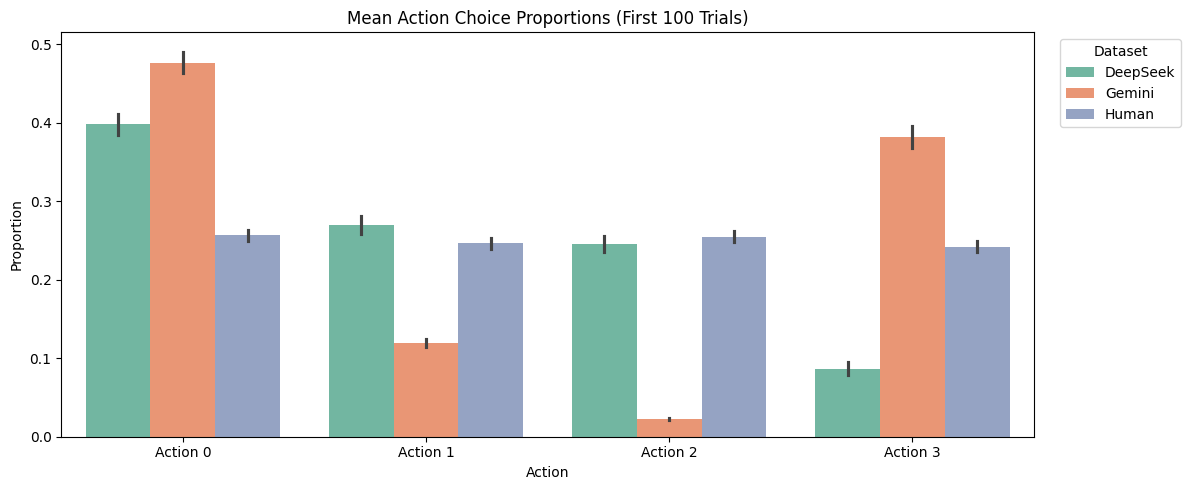

In [13]:
long_props = session_df.melt(
    id_vars=["dataset", "variant", "session_id"],
    value_vars=["p_action_0", "p_action_1", "p_action_2", "p_action_3"],
    var_name="action",
    value_name="proportion"
)
long_props["action"] = long_props["action"].str.replace("p_action_", "Action ")

plt.figure(figsize=(12,5))

sns.barplot(
    data=long_props,
    x="action",
    y="proportion",
    hue="dataset",
    errorbar="se",
    palette="Set2"
)

plt.title("Mean Action Choice Proportions (First 100 Trials)")
plt.ylabel("Proportion")
plt.xlabel("Action")

plt.legend(title="Dataset", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

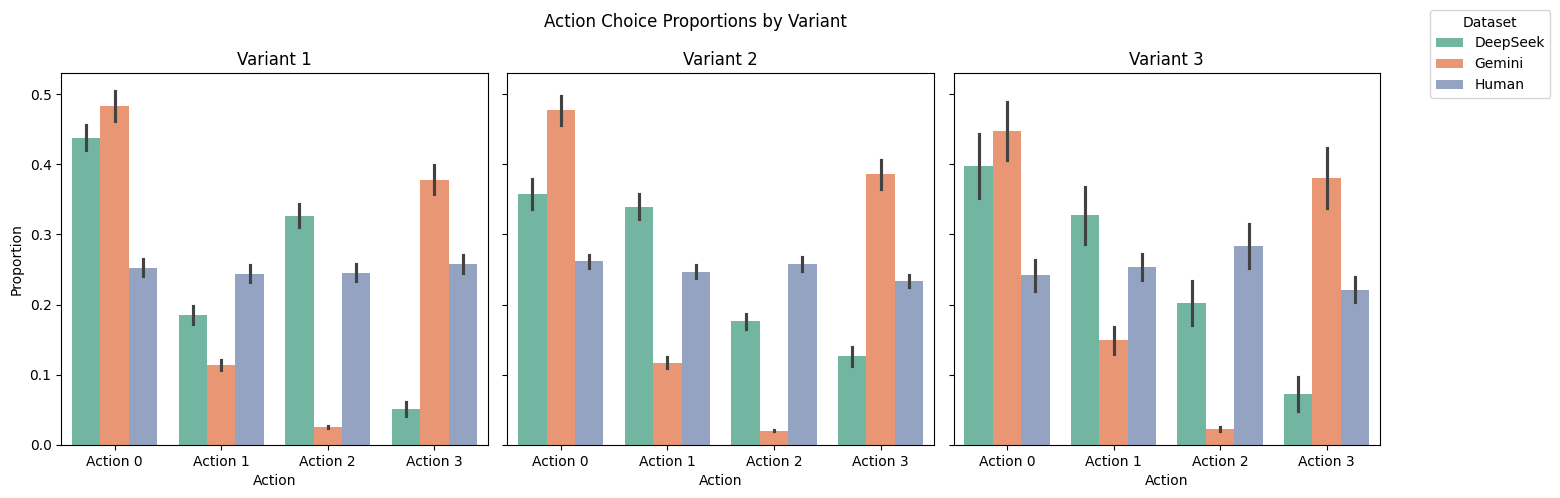

In [14]:
variants = sorted(long_props["variant"].unique())

fig, axes = plt.subplots(1, len(variants), figsize=(14,5), sharey=True)

for i, v in enumerate(variants):
    sns.barplot(
        data=long_props[long_props["variant"] == v],
        x="action",
        y="proportion",
        hue="dataset",
        errorbar="se",
        palette="Set2",
        ax=axes[i]
    )
    
    axes[i].set_title(f"Variant {v}")
    axes[i].set_xlabel("Action")
    
    if i == 0:
        axes[i].set_ylabel("Proportion")
    else:
        axes[i].set_ylabel("")

    axes[i].legend().remove()

# shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Dataset", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.suptitle("Action Choice Proportions by Variant")
plt.tight_layout()
plt.show()

* Humans show near-uniform action distributions across all variants → balanced exploration
* Gemini show strong concentration on two actions → highly deterministic and exploitative behaviour
* DeepSeek show moderate but inconsistent preferences (favour one action but more spreaded compared to Gemini)

## Advantageous choice rate over time

/tmp/ipykernel_837273/1639254410.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_block.groupby(["dataset","variant","block"])["reward"]


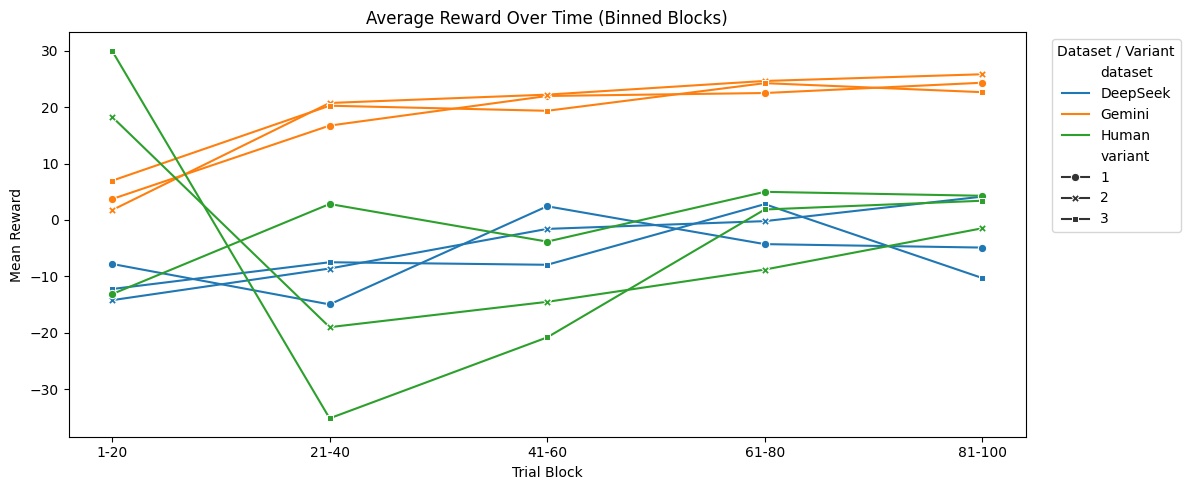

In [15]:
df_block = df.copy()

# create trial blocks
df_block["block"] = pd.cut(
    df_block["trial_number"],
    bins=[0,20,40,60,80,100],
    labels=["1-20","21-40","41-60","61-80","81-100"]
)

# mean reward per block
block_means = (
    df_block.groupby(["dataset","variant","block"])["reward"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=block_means,
    x="block",
    y="reward",
    hue="dataset",
    style="variant",
    markers=True,
    dashes=False
)

plt.title("Average Reward Over Time (Binned Blocks)")
plt.xlabel("Trial Block")
plt.ylabel("Mean Reward")

plt.legend(title="Dataset / Variant", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

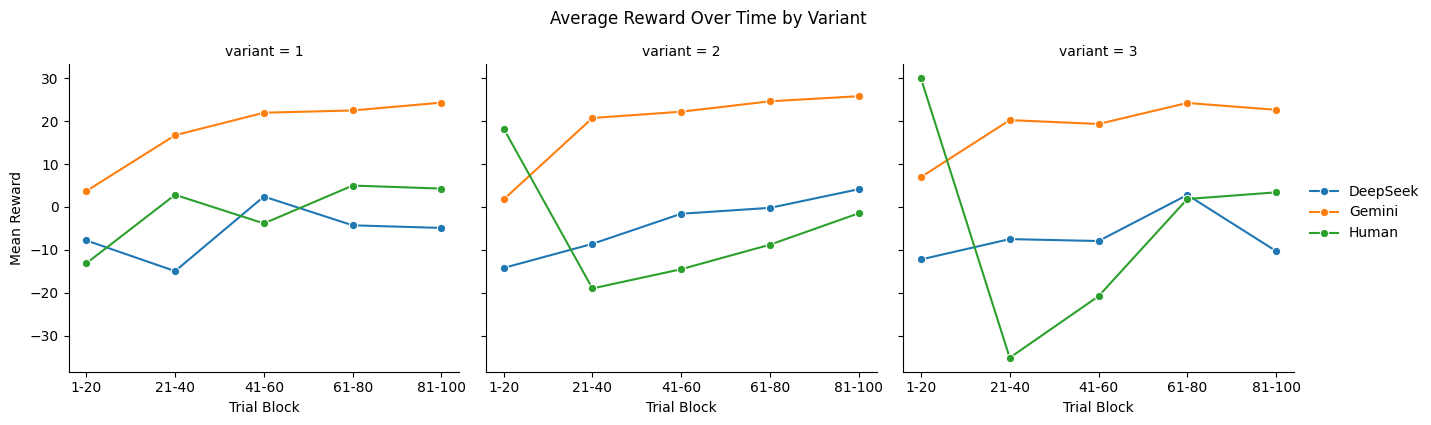

In [16]:
graph = sns.FacetGrid(
    block_means,
    col="variant",
    height=4,
    aspect=1.1,
    sharey=True
)

graph.map_dataframe(
    sns.lineplot,
    x="block",
    y="reward",          
    hue="dataset",
    marker="o"
)

graph.add_legend()

graph.set_axis_labels("Trial Block", "Mean Reward")

graph.fig.suptitle(
    "Average Reward Over Time by Variant",
    y=1.05
)

plt.show()

In [17]:
# Reward per block (learning)
block_means.groupby(["dataset", "variant", "block"])["reward"].mean()

/tmp/ipykernel_837273/775171869.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  block_means.groupby(["dataset", "variant", "block"])["reward"].mean()


dataset   variant  block 
DeepSeek  1        1-20      -7.800000
                   21-40    -14.975000
                   41-60      2.425000
                   61-80     -4.287500
                   81-100    -4.900000
          2        1-20     -14.225000
                   21-40     -8.612500
                   41-60     -1.587500
                   61-80     -0.212500
                   81-100     4.137500
          3        1-20     -12.250000
                   21-40     -7.500000
                   41-60     -7.950000
                   61-80      2.800000
                   81-100   -10.300000
Gemini    1        1-20       3.700000
                   21-40     16.725000
                   41-60     21.975000
                   61-80     22.500000
                   81-100    24.325000
          2        1-20       1.737500
                   21-40     20.737500
                   41-60     22.212500
                   61-80     24.637500
                   81-100    25.825000

* Gemini demonstrated clear and consistent learning across all variants → strong and stable improvement over time
* Humans showed weaker and more variable learning patterns → difficulty adapting to task constraints
* DeepSeek showed poor and inconsistent learning across all variants → weak or ineffective learning from experience

## Loss sensitivity (switch-after-loss rate)

In [18]:
# Loss sensitivity
session_df.groupby(["dataset", "variant"])["loss_sensitivity"].describe()

count      mean       std       min       25%       50%  \
dataset  variant                                                            
DeepSeek 1        200.0  0.486797  0.145602  0.163265  0.384615  0.461538   
         2        200.0  0.609518  0.142905  0.220000  0.500000  0.619869   
         3         50.0  0.469771  0.161674  0.131579  0.365865  0.481685   
Gemini   1        200.0  0.278752  0.133695  0.050000  0.166667  0.266968   
         2        200.0  0.270008  0.135016  0.069767  0.165698  0.238095   
         3         50.0  0.278957  0.140338  0.104167  0.167857  0.260150   
Human    1        159.0  0.732764  0.246129  0.023810  0.571429  0.818182   
         2        222.0  0.681946  0.254939  0.029412  0.503049  0.750000   
         3         29.0  0.772797  0.254570  0.100000  0.615385  0.842105   

                       75%       max  
dataset  variant                      
DeepSeek 1        0.584559  0.933333  
         2        0.707983  0.888889  
         3        0.558889  0.880000  
Gemini   1        0.365320  0.714286  
         2        0.337500  0.666667  
         3        0.352941  0.750000  
Human    1        0.925824  1.000000  
         2        0.892616  1.000000  
         3        0.965517  1.000000

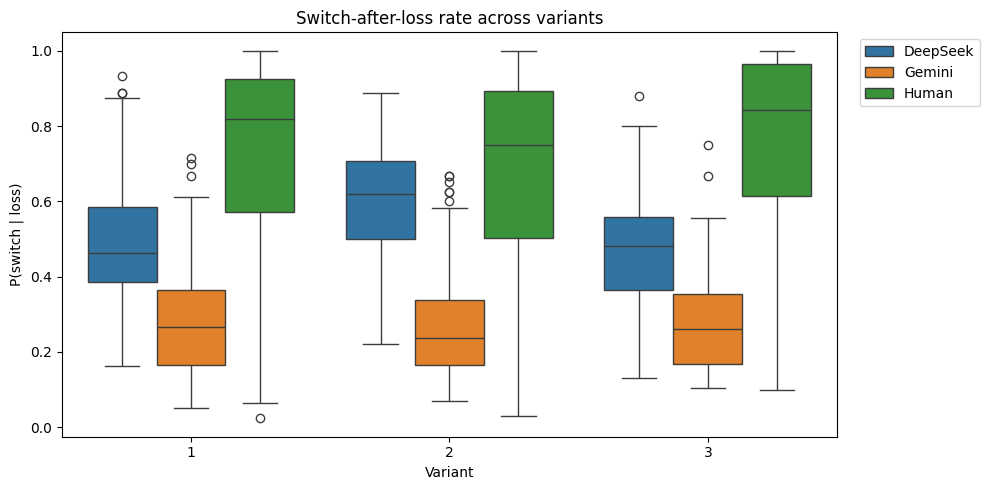

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(data=session_df, x="variant", y="loss_sensitivity", hue="dataset")
plt.title("Switch-after-loss rate across variants")
plt.xlabel("Variant")
plt.ylabel("P(switch | loss)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

* Humans exhibited the highest loss sensitivity across all variants → strong tendency to switch actions after negative outcomes
* DeepSeek showed moderate loss sensitivity → some responsiveness to negative feedback, though less consistent than humans
* Gemini exhibited consistently low loss sensitivity → a reduced tendency to adjust behaviour following losses